In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
from torchvision.models import inception_v3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import numpy as np
import pandas as pd
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

c:\Users\Wall-E\.conda\envs\vakkas\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] Belirtilen yordam bulunamadı'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
# Veri kümesini yükleme
DATASET_PATH = "kvasir-dataset-v2"  # Buraya veri kümenizin yolunu ekleyin
RESULTS_DIR = "inception_v3"  # Kayıt klasörü
os.makedirs(RESULTS_DIR, exist_ok=True)

In [3]:
# Görüntü boyutu ve batch size
target_size = (299, 299)  # alexnet için uygun boyut
batch_size = 32

# Veri ön işleme
transform = transforms.Compose([
    transforms.Resize(target_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [4]:
# Tüm veri kümesini yükleme
full_dataset = ImageFolder(root=os.path.join(DATASET_PATH), transform=transform)

# Veri kümesini bölme (70% train, 20% validation, 10% test)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.2 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
# Inception-v3 Modeli
model = inception_v3(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 8)  # 6 sınıf için güncellendi

c:\Users\Wall-E\.conda\envs\vakkas\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Wall-E\.conda\envs\vakkas\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")  # GPU 1 kullanımı için güncellendi
model.to(device)

print(f"using device: {device}")
devNumber=torch.cuda.current_device()
print(f"curennt device number is:{devNumber}")
devName=torch.cuda.get_device_name()
print(f"gpu name is {devName}")

using device: cuda:0
curennt device number is:0
gpu name is NVIDIA RTX A5000


In [7]:
# Kayıp fonksiyonu ve optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Sonuçları kaydetmek için boş bir DataFrame oluşturma
results = []

In [8]:
# Modeli eğitme
epochs = 50
train_losses, val_accuracies = [], []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        # Eğer model birden fazla çıktı döndürüyorsa, sadece ana çıktıyı kullan
        if isinstance(outputs, tuple) or isinstance(outputs, torch.nn.modules.container.Outputs):
            outputs = outputs[0]  # İlk eleman ana logits çıktısıdır
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    # Doğrulama testi
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')
    val_accuracies.append(accuracy)

     # Sonuçları kaydet
    results.append([epoch + 1, train_losses[-1], accuracy, precision, recall, f1])
    print(
        f"Epoch {epoch + 1}/{epochs}, Loss: {train_losses[-1]:.4f}, Val Acc: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Epoch 1/50, Loss: 0.5349, Val Acc: 0.9056, Precision: 0.9101, Recall: 0.9038, F1: 0.9031
Epoch 2/50, Loss: 0.1852, Val Acc: 0.9256, Precision: 0.9242, Recall: 0.9232, F1: 0.9231
Epoch 3/50, Loss: 0.0862, Val Acc: 0.9237, Precision: 0.9222, Recall: 0.9215, F1: 0.9214
Epoch 4/50, Loss: 0.0625, Val Acc: 0.9269, Precision: 0.9250, Recall: 0.9243, F1: 0.9244
Epoch 5/50, Loss: 0.0551, Val Acc: 0.9344, Precision: 0.9329, Recall: 0.9325, F1: 0.9323
Epoch 6/50, Loss: 0.0327, Val Acc: 0.9269, Precision: 0.9286, Recall: 0.9246, F1: 0.9245
Epoch 7/50, Loss: 0.0372, Val Acc: 0.9244, Precision: 0.9254, Recall: 0.9230, F1: 0.9227
Epoch 8/50, Loss: 0.0382, Val Acc: 0.9269, Precision: 0.9255, Recall: 0.9249, F1: 0.9245
Epoch 9/50, Loss: 0.0235, Val Acc: 0.9213, Precision: 0.9205, Recall: 0.9189, F1: 0.9189
Epoch 10/50, Loss: 0.0418, Val Acc: 0.9256, Precision: 0.9242, Recall: 0.9234, F1: 0.9235
Epoch 11/50, Loss: 0.0311, Val Acc: 0.9256, Precision: 0.9242, Recall: 0.9241, F1: 0.9239
Epoch 12/50, Loss: 

In [9]:
# Sonuçları Excel'e kaydetme
df_results = pd.DataFrame(results,
                          columns=["Epoch", "Train Loss", "Validation Accuracy", "Precision", "Recall", "F1 Score"])
df_results.to_excel(os.path.join(RESULTS_DIR,"training_results.xlsx"), index=False)

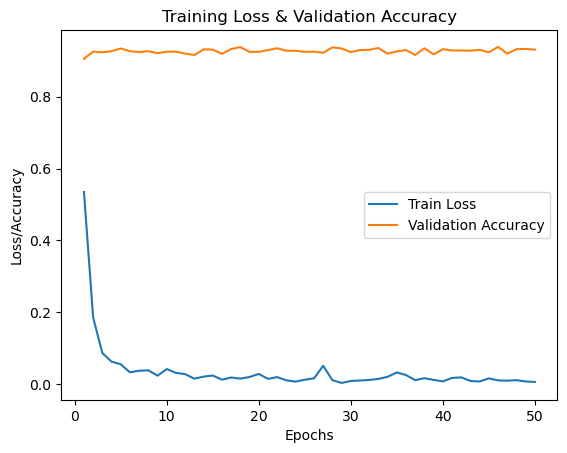

In [10]:
# Eğitim ve doğrulama kayıplarını görselleştirme
plt.figure()
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.title('Training Loss & Validation Accuracy')
plt.savefig(os.path.join(RESULTS_DIR,"training_plot.png"))
plt.show()

In [11]:
# Test sonuçları
test_results = []
test_correct, test_total = 0, 0
all_preds, all_labels = [], []
all_probs = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        _, predicted = torch.max(outputs, 1)
        all_probs.extend(probs)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
conf_matrix = confusion_matrix(all_labels, all_preds)

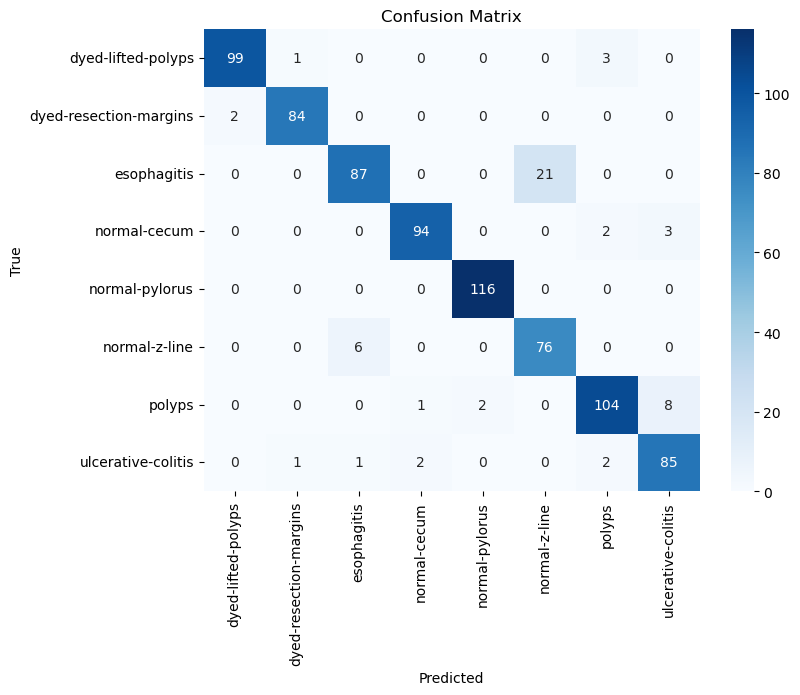

In [12]:
# Confusion matrix çizimi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(RESULTS_DIR,"confusion_matrix.png"))
plt.show()

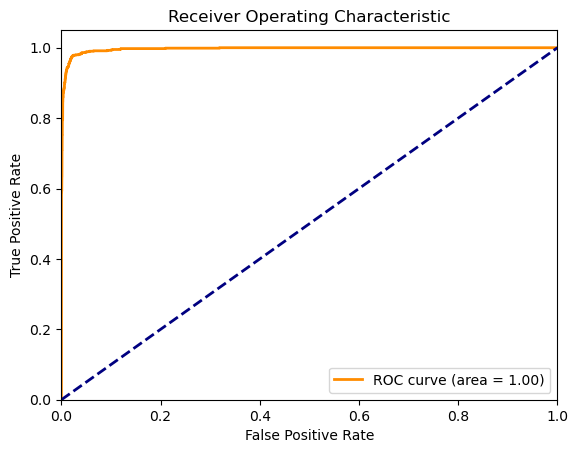

In [13]:
# ROC-AUC Eğrisi
all_labels_bin = label_binarize(all_labels, classes=range(8))
all_probs = np.array(all_probs)
fpr, tpr, _ = roc_curve(all_labels_bin.ravel(), all_probs.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.savefig(os.path.join(RESULTS_DIR,"roc_curve.png"))
plt.show()

In [14]:
test_results.append([test_acc, precision, recall, f1])
df_test_results = pd.DataFrame(test_results, columns=["Test Accuracy", "Precision", "Recall", "F1 Score"])
df_test_results.to_excel(os.path.join(RESULTS_DIR,"testing_results.xlsx"), index=False)

print(f'Test Accuracy: {test_acc * 100:.2f}%')
print(f'Confusion Matrix:\n{conf_matrix}')

Test Accuracy: 93.12%
Confusion Matrix:
[[ 99   1   0   0   0   0   3   0]
 [  2  84   0   0   0   0   0   0]
 [  0   0  87   0   0  21   0   0]
 [  0   0   0  94   0   0   2   3]
 [  0   0   0   0 116   0   0   0]
 [  0   0   6   0   0  76   0   0]
 [  0   0   0   1   2   0 104   8]
 [  0   1   1   2   0   0   2  85]]
